# Week 10 Instructor-led Lab: Decision Trees

Author: Hali Evans    
Course: BGEN632    
Purpose: Practice implementing decision trees in Python.

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# for pca
from sklearn import preprocessing
from sklearn.decomposition import PCA as pca

# for factor analysis
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo

# for k-means clustering 
import sklearn.metrics as metcs
from scipy.cluster import hierarchy as hier
from sklearn import cluster as cls

# for decision tree 
from sklearn.feature_extraction.image import grid_to_graph
from sklearn import tree

# modules for plotting trees
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display

In [5]:
# set working directory
os.chdir("/Users/halievans/Documents/BGEN632/week10labs/data")  # add your filepath within the quotes
os.getcwd()  # confirm change

'/Users/halievans/Documents/BGEN632/week10labs/data'

In [6]:
# load data
hospital_df = pd.read_csv("calihospital.txt", sep="\t")
hospital_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HospitalID     61 non-null     int64  
 1   Name           61 non-null     object 
 2   Zip            61 non-null     object 
 3   Website        61 non-null     object 
 4   TypeControl    61 non-null     object 
 5   Teaching       61 non-null     object 
 6   DonorType      61 non-null     object 
 7   NoFTE          61 non-null     float64
 8   NetPatRev      61 non-null     float64
 9   InOperExp      61 non-null     float64
 10  OutOperExp     61 non-null     float64
 11  OperRev        61 non-null     int64  
 12  OperInc        61 non-null     int64  
 13  AvlBeds        61 non-null     int64  
 14  Work_ID        61 non-null     int64  
 15  LastName       61 non-null     object 
 16  FirstName      61 non-null     object 
 17  Gender         61 non-null     object 
 18  PositionID  

In [7]:
# convert categorical variables usine onehot
hospital_df_2 = pd.get_dummies(hospital_df[['TypeControl', 'Teaching', 'DonorType']], drop_first=True)

# combine predictors
hospital_df_trees = pd.concat([
    hospital_df_2, 
    hospital_df[['NoFTE', 'AvlBeds', 'InOperExp']]], axis=1)

# finalize list
col_names = list(hospital_df_trees.columns)

## Regression Trees

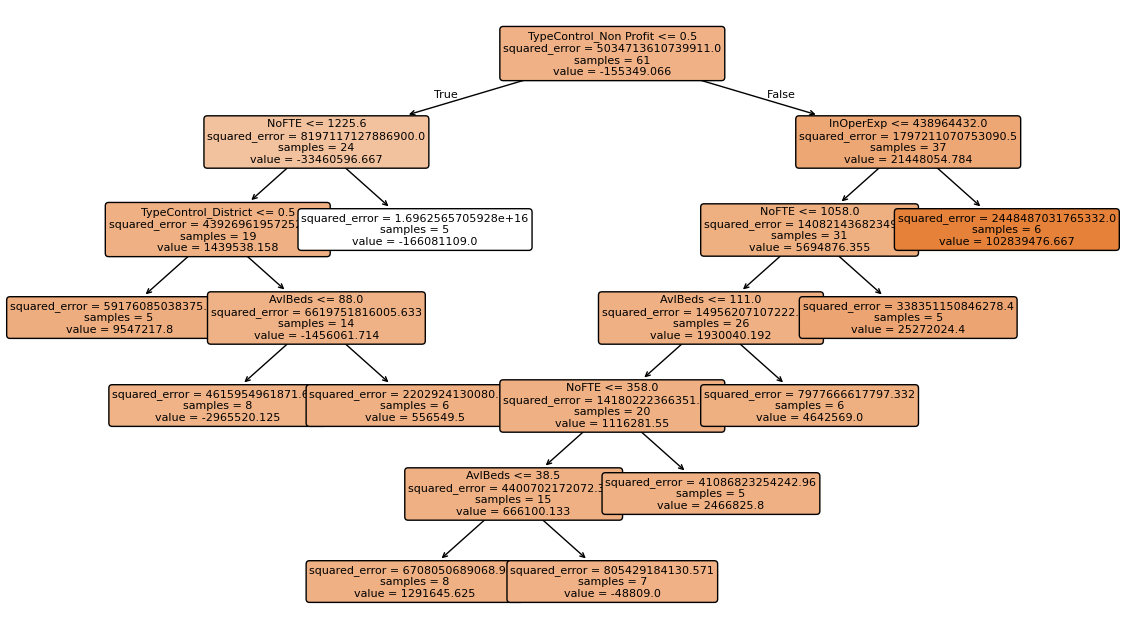

In [9]:
# regression tree operating income
tree_model = tree.DecisionTreeRegressor(min_samples_split=5, min_samples_leaf=5)
tree_model.fit(hospital_df_trees, hospital_df.loc[hospital_df_trees.index, 'OperInc'])

# plot tree
plt.figure(figsize=(14, 8))
tree.plot_tree(tree_model,
               feature_names=col_names, 
               filled=True, rounded=True, 
               fontsize=8)
plt.show()

Findings:    
The top of the tree splits on "TypeControl_Non Profit" and "NoFTE" as the higher levels. This suggests that whether an organization is Non Profit and the amount of FTE are strong initial indicators of its operating income.      
Split Reasoning:    
The number of employees at a company are often correlated to operations as the payroll on this is often large.
While the availability of beds is not as related to the operating income as there are certain restriction such as space 

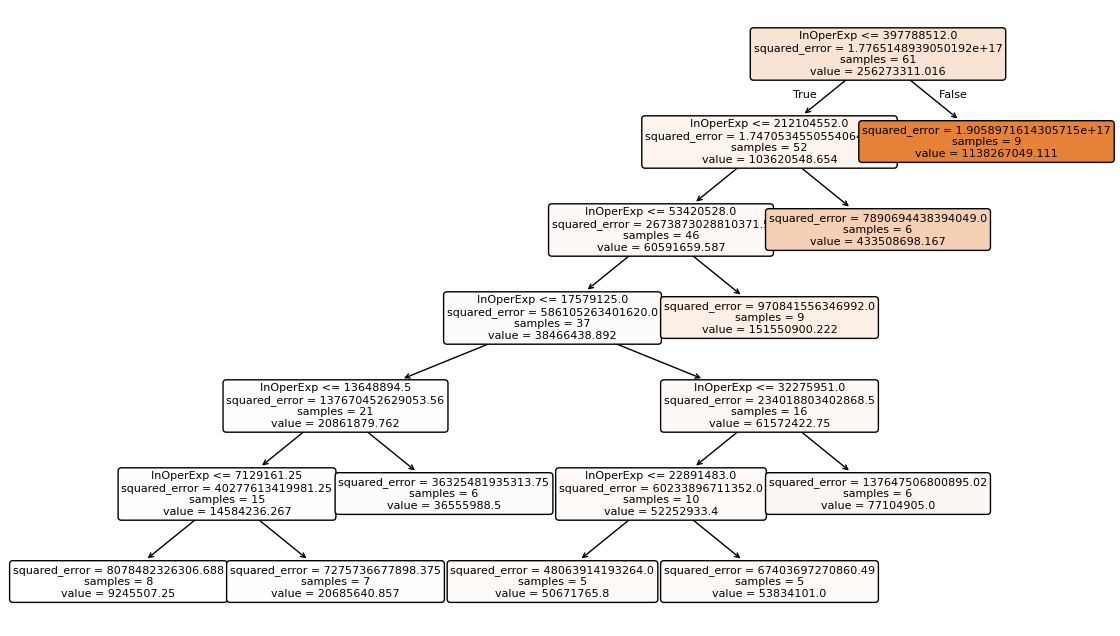

In [10]:
# regression tree operating revenue
tree_model = tree.DecisionTreeRegressor(min_samples_split=5, min_samples_leaf=5)
tree_model.fit(hospital_df_trees, hospital_df.loc[hospital_df_trees.index, 'OperRev'])

# plot tree
plt.figure(figsize=(14, 8))
tree.plot_tree(tree_model,
               feature_names=col_names, 
               filled=True, rounded=True, 
               fontsize=8)
plt.show()

Findings:    
This tree splits on "InOperExp" at various thresholds. The predicted values vary significantly based on these.    
Split Reasoning:    
Inpatient operating expenses relate to financial ability in healthcare. When expenses are higher there is often a larger operation taking place.

## Classification Trees

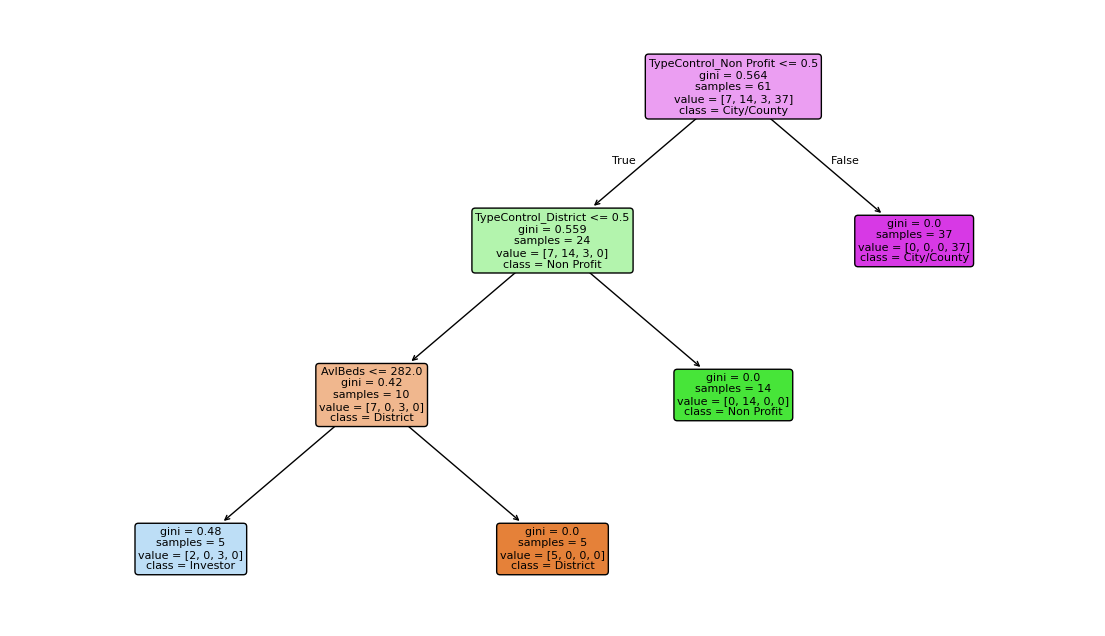

In [12]:
# classification tree TypeControl
# get class names
cls_names = hospital_df['TypeControl'].unique().tolist()

# fit classifier
tree_model = tree.DecisionTreeClassifier(min_samples_split=5, min_samples_leaf=5)
tree_model.fit(hospital_df_trees, hospital_df.loc[hospital_df_trees.index, 'TypeControl'])

# plot tree
plt.figure(figsize=(14, 8))
tree.plot_tree(tree_model, 
               feature_names=col_names, 
               class_names=cls_names, 
               filled=True, 
               rounded=True, 
               fontsize=8)
plt.show()

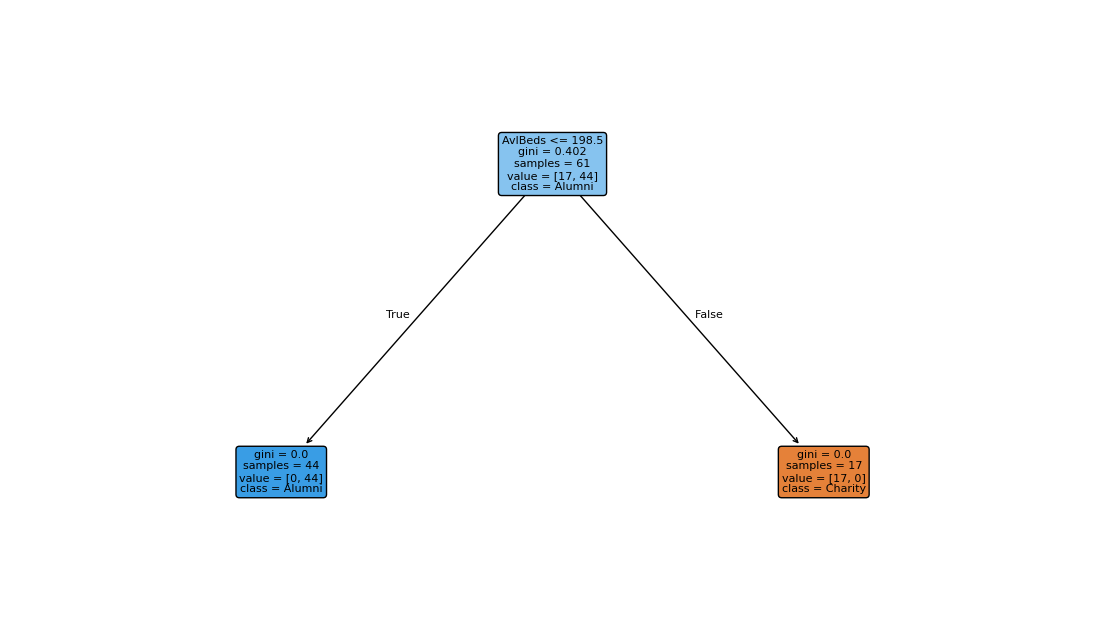

In [13]:
# classification tree DonorType
# get class names
cls_names = hospital_df['DonorType'].unique().tolist()

# fit classifier
tree_model = tree.DecisionTreeClassifier(min_samples_split=5, min_samples_leaf=5)
tree_model.fit(hospital_df_trees, hospital_df.loc[hospital_df_trees.index, 'DonorType'])

# plot tree
plt.figure(figsize=(14, 8))
tree.plot_tree(tree_model, 
               feature_names=col_names, 
               class_names=cls_names, 
               filled=True, 
               rounded=True, 
               fontsize=8)
plt.show()

Findings:    
This simple tree classifies donors into two groups: "Alumni" and "Charity," based on the number of beds available. Organizations with fewer beds are "Alumni", while those with more beds are "Charity".    
Split Reasoning:    
This split does not make as much sense because "DonorType" does not usually dictate the availibility of beds. 

#### Best Model: Classification Tree TypeControl
The first division based on "TypeControl_Non Profit" is crucial and significantly influences how we classify an organization. This makes it a strong and meaningful separation. The additional splits within the non-profit category, focusing on "TypeControl District" and "AvlBeds," provide ways to distinguish between different types of non-profits. The Regression Tree Operating Income although could have a strong impact it is extremely hard to read and understand. 